In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
import zipfile

with zipfile.ZipFile("flowers.zip", 'r') as zip_ref:
    zip_ref.extractall("flowers")

print("Dataset unzipped to /content/flowers")



Dataset unzipped to /content/flowers


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

img_size = 128
dataset_path = 'flowers/flowers'

def load_images_labels(path, img_size):
    images, labels = [], []
    class_names = sorted(os.listdir(path))
    class_map = {name: idx for idx, name in enumerate(class_names)}
    for class_name in class_names:
        class_dir = os.path.join(path, class_name)
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(class_map[class_name])
    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_images_labels(dataset_path, img_size)
images = images.astype('float32') / 255.0
print(f" Loaded {len(images)} images across {len(class_names)} classes: {class_names}")


 Loaded 4317 images across 5 classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [ ]:
input_img = Input(shape=(img_size, img_size, 3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, validation_data=(X_test, X_test))


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 385s 7s/step - loss: 0.0624 - val_loss: 0.0241
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 376s 7s/step - loss: 0.0210 - val_loss: 0.0162
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 387s 7s/step - loss: 0.0149 - val_loss: 0.0137
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 362s 7s/step - loss: 0.0134 - val_loss: 0.0130
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 358s 7s/step - loss: 0.0125 - val_loss: 0.0115
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - loss: 0.0117 - val_loss: 0.0111
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 384s 7s/step - loss: 0.0109 - val_loss: 0.0107
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 358s 7s/step - loss: 0.0108 - val_loss: 0.0105
Epoch 9/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 400s 7s/step - loss: 0.0102 - val_loss: 0.0106
Epoch 10/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 382s 7s/step - loss: 0.0102 - val_loss: 0.0104


In [ ]:
encoder = Model(inputs=autoencoder.input, outputs=encoded)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

X_train_flat = X_train_encoded.reshape((X_train_encoded.shape[0], -1))
X_test_flat = X_test_encoded.reshape((X_test_encoded.shape[0], -1))


108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 349ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step


In [ ]:
# Train a classifier on top of encoded features extracted from the autoencoder
# This helps us test if the autoencoder has learned meaningful representations
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Using logistic regression as a simple yet effective dense classifier
dense_clf = LogisticRegression(max_iter=1000)
dense_clf.fit(X_train_flat, y_train)

# Make predictions on the test set
y_pred_dense = dense_clf.predict(X_test_flat)

# Print accuracy and classification report for performance evaluation
print("Dense Classifier Accuracy on Encoded Features:", accuracy_score(y_test, y_pred_dense))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dense, target_names=class_names))


Dense Classifier Accuracy on Encoded Features: 0.5902777777777778

Classification Report:
               precision    recall  f1-score   support

       daisy       0.50      0.51      0.50       162
   dandelion       0.67      0.75      0.71       223
        rose       0.57      0.48      0.52       155
   sunflower       0.69      0.64      0.66       135
       tulip       0.52      0.52      0.52       189

    accuracy                           0.59       864
   macro avg       0.59      0.58      0.58       864
weighted avg       0.59      0.59      0.59       864



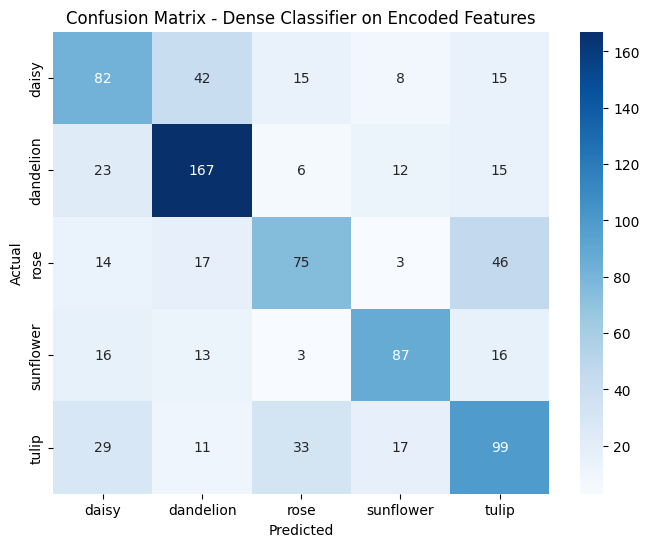

In [ ]:
# Visualizing model performance using a confusion matrix
# Helps identify which flower classes are being confused the most

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_dense), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Dense Classifier on Encoded Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Building a baseline CNN model for flower classification
# This model is trained directly on raw image pixels (no autoencoder involved)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(class_names), activation='softmax')  # Output layer with softmax for multi-class classification
])

# Compile the model using Adam optimizer and cross-entropy loss
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model architecture summary
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,965 (28.20 MB)

 Trainable params: 7,392,965 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the CNN model on raw images
# This will serve as a benchmark to compare against the autoencoder-based approach

history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2525 - loss: 2.1748 - val_accuracy: 0.4711 - val_loss: 1.2772
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.5104 - loss: 1.1950 - val_accuracy: 0.5278 - val_loss: 1.1245
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6084 - loss: 0.9735 - val_accuracy: 0.5775 - val_loss: 1.0099
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7025 - loss: 0.7838 - val_accuracy: 0.6146 - val_loss: 0.9646
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8004 - loss: 0.5765 - val_accuracy: 0.6042 - val_loss: 1.0214
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8510 - loss: 0.4516 - val_accuracy: 0.6296 - val_loss: 1.0853
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9007 - loss: 0.2972 - val_accuracy: 0.6192 - val_loss: 1.1440
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9396 - loss: 0.2038 - val_accuracy: 0.6065 - v

In [ ]:
# Evaluate performance of the CNN model on the test set
# Provides classification report and confusion matrix for deeper insights

y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

print("CNN Model Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cnn, target_names=class_names))


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 523ms/step
CNN Model Accuracy: 0.6041666666666666

Classification Report:
               precision    recall  f1-score   support

       daisy       0.65      0.51      0.57       162
   dandelion       0.69      0.67      0.68       223
        rose       0.50      0.45      0.47       155
   sunflower       0.62      0.73      0.67       135
       tulip       0.55      0.63      0.59       189

    accuracy                           0.60       864
   macro avg       0.60      0.60      0.60       864
weighted avg       0.61      0.60      0.60       864



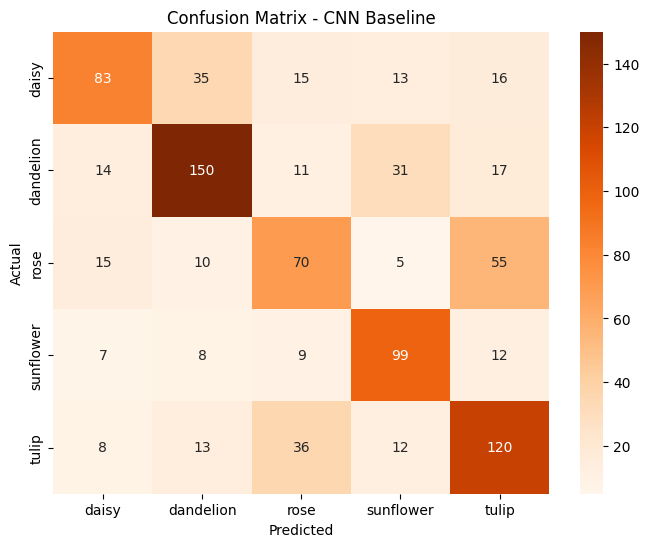

In [ ]:
# Visualizing CNN results using confusion matrix

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CNN Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Import required modules for transfer learning with ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Preprocess inputs using ResNet50's expected input format
X_train_resnet = preprocess_input(X_train.copy() * 255.0)
X_test_resnet = preprocess_input(X_test.copy() * 255.0)

# Load pre-trained ResNet50 (excluding top dense layers)
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))

# Freeze base model layers so they are not updated during training
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
resnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet50 model
# Since we're using a frozen base, training should be relatively fast

history_resnet = resnet_model.fit(
    X_train_resnet, y_train,
    validation_data=(X_test_resnet, y_test),
    epochs=5,
    batch_size=32
)


Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.6737 - loss: 1.0519 - val_accuracy: 0.8333 - val_loss: 0.4594
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.8880 - loss: 0.3129 - val_accuracy: 0.8345 - val_loss: 0.4600
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.9245 - loss: 0.2194 - val_accuracy: 0.8461 - val_loss: 0.4496
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.9463 - loss: 0.1667 - val_accuracy: 0.8530 - val_loss: 0.4425
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 321s 3s/step - accuracy: 0.9594 - loss: 0.1200 - val_accuracy: 0.8588 - val_loss: 0.4632


In [ ]:
# Evaluate performance of ResNet50 model
y_pred_resnet = np.argmax(resnet_model.predict(X_test_resnet), axis=1)

print("ResNet50 Accuracy:", accuracy_score(y_test, y_pred_resnet))
print("\nClassification Report:\n", classification_report(y_test, y_pred_resnet, target_names=class_names))


27/27 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step
ResNet50 Accuracy: 0.8587962962962963

Classification Report:
               precision    recall  f1-score   support

       daisy       0.86      0.87      0.87       162
   dandelion       0.89      0.87      0.88       223
        rose       0.84      0.82      0.83       155
   sunflower       0.83      0.88      0.86       135
       tulip       0.86      0.85      0.85       189

    accuracy                           0.86       864
   macro avg       0.86      0.86      0.86       864
weighted avg       0.86      0.86      0.86       864



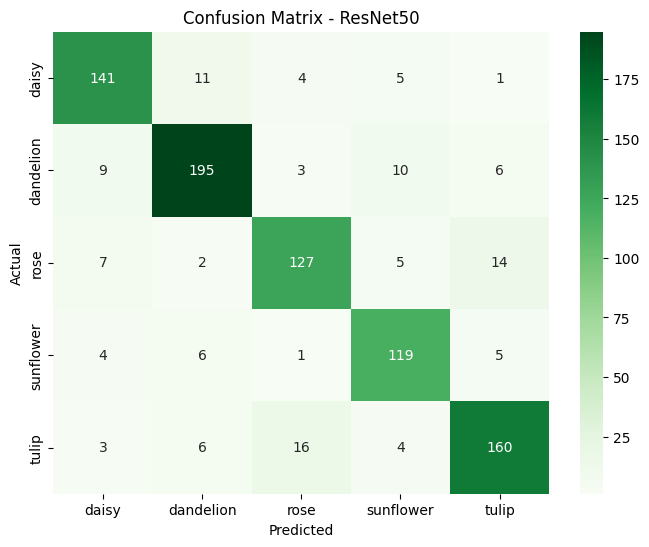

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_resnet), annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Import necessary modules
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D

# Preprocess images for MobileNetV2
X_train_mobilenet = mobilenet_preprocess(X_train.copy() * 255.0)
X_test_mobilenet = mobilenet_preprocess(X_test.copy() * 255.0)

# Load base MobileNetV2 model with pre-trained weights
base_model_mn = MobileNetV2(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))
base_model_mn.trainable = False  # Freeze the base layers

# Add custom classification head
x = base_model_mn.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

mobilenet_model = Model(inputs=base_model_mn.input, outputs=predictions)

# Compile the model
mobilenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Training MobileNetV2
history_mobilenet = mobilenet_model.fit(
    X_train_mobilenet, y_train,
    validation_data=(X_test_mobilenet, y_test),
    epochs=5,
    batch_size=32
)


Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 80s 677ms/step - accuracy: 0.6733 - loss: 0.8734 - val_accuracy: 0.8264 - val_loss: 0.4619
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 77s 635ms/step - accuracy: 0.8887 - loss: 0.3079 - val_accuracy: 0.8484 - val_loss: 0.3949
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 81s 627ms/step - accuracy: 0.9310 - loss: 0.2043 - val_accuracy: 0.8588 - val_loss: 0.3903
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 79s 598ms/step - accuracy: 0.9463 - loss: 0.1479 - val_accuracy: 0.8472 - val_loss: 0.4229
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 67s 620ms/step - accuracy: 0.9632 - loss: 0.1185 - val_accuracy: 0.8681 - val_loss: 0.4027


In [ ]:
# Make predictions and evaluate performance
y_pred_mobilenet = np.argmax(mobilenet_model.predict(X_test_mobilenet), axis=1)

print("MobileNetV2 Accuracy:", accuracy_score(y_test, y_pred_mobilenet))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mobilenet, target_names=class_names))


27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 438ms/step
MobileNetV2 Accuracy: 0.8680555555555556

Classification Report:
               precision    recall  f1-score   support

       daisy       0.82      0.89      0.85       162
   dandelion       0.90      0.89      0.89       223
        rose       0.85      0.85      0.85       155
   sunflower       0.90      0.82      0.86       135
       tulip       0.87      0.87      0.87       189

    accuracy                           0.87       864
   macro avg       0.87      0.86      0.87       864
weighted avg       0.87      0.87      0.87       864



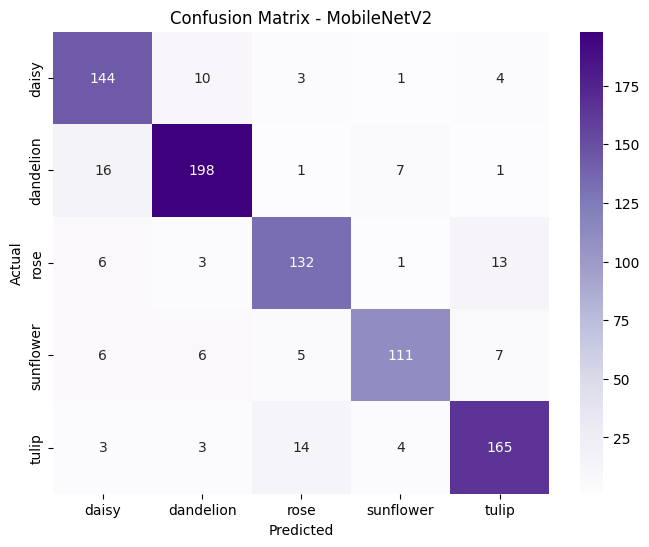

In [ ]:
# Visualize prediction performance using confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_mobilenet), annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import cv2
from tensorflow.keras.models import Model

def get_gradcam_heatmap(model, image, class_index, last_conv_layer_name):
    # Create a model that maps input image to activations and predictions
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.expand_dims(image, axis=0))
        loss = predictions[:, class_index]

    # Gradient of the class output value with respect to the feature map
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel by "importance"
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()


In [ ]:
def show_gradcam(image, heatmap, alpha=0.4, cmap='jet'):
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_colored = plt.cm.get_cmap(cmap)(heatmap_resized)
    heatmap_colored = np.delete(heatmap_colored, 3, 2)  # remove alpha channel

    # Superimpose heatmap
    superimposed_img = heatmap_colored * alpha + image
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Display
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Grad-CAM")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


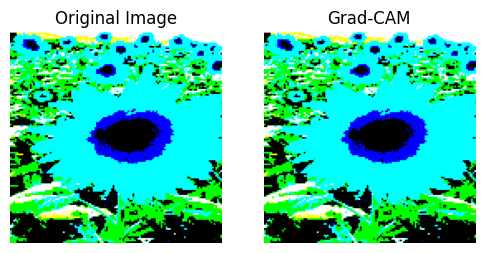

In [ ]:
# Pick one image and predict its class
sample_idx = 10
sample_image = X_test_resnet[sample_idx]
sample_label = y_test[sample_idx]

# Predict class
preds = resnet_model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(preds)

# Generate Grad-CAM heatmap
heatmap = get_gradcam_heatmap(resnet_model, sample_image, predicted_class, last_conv_layer_name="conv5_block3_out")

# Show Grad-CAM visualization
show_gradcam(sample_image, heatmap)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


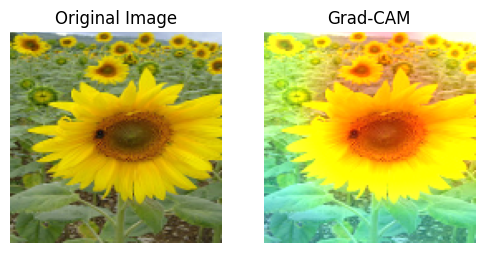

In [ ]:
# Use same index for comparison
sample_image_mn = X_test_mobilenet[sample_idx]

# Predict class
preds_mn = mobilenet_model.predict(np.expand_dims(sample_image_mn, axis=0))
predicted_class_mn = np.argmax(preds_mn)

# Grad-CAM from MobileNetV2
heatmap_mn = get_gradcam_heatmap(mobilenet_model, sample_image_mn, predicted_class_mn, last_conv_layer_name="Conv_1")

# Show Grad-CAM result
show_gradcam(X_test[sample_idx], heatmap_mn)
